# Загрузка данных

In [3]:
from google.colab import userdata
import json
import os

KAGGLE_JSON_PATH = os.path.expanduser("~/.config/kaggle/kaggle.json")

kaggle_dir = os.path.dirname(KAGGLE_JSON_PATH)
os.makedirs(kaggle_dir, exist_ok=True)

kaggle_json = json.loads(userdata.get("kaggle_json"))

with open(KAGGLE_JSON_PATH, "w") as f:
    json.dump(kaggle_json, f)

!chmod 600 ~/.config/kaggle/kaggle.json

!kaggle competitions download -c scintillation-detector
!unzip /content/scintillation-detector.zip

  0% 0.00/13.2M [00:00<?, ?B/s]
100% 13.2M/13.2M [00:00<00:00, 849MB/s]
Archive:  /content/scintillation-detector.zip
  inflating: Description.pdf         
  inflating: Run200_Wave_0_1.txt     
  inflating: test-dataset.ipynb      


# Анализ датасета

In [9]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
import re

plt.style.use("ggplot")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)

df = pd.read_csv("/content/Run200_Wave_0_1.txt", sep=" ", header=None, skipinitialspace=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23479 entries, 0 to 23478
Columns: 505 entries, 0 to 504
dtypes: float64(1), int64(504)
memory usage: 90.5 MB


In [10]:
df.isna().sum()

,0
0,0
1,0
2,0
3,0
4,0
...,...
500,0
501,0
502,0
503,0


In [11]:
print(f"Total objects: {len(df)}")

print(f"Total missing values: {df.isna().iloc[:,0].sum()}")

print()

print(f"Number of   numerical columns: {df.dtypes[df.dtypes != "object"].value_counts().sum()}")
print(f"Number of categorical columns: {df.dtypes[df.dtypes == "object"].value_counts().sum()}")

Total objects: 23479
Total missing values: 0

Number of   numerical columns: 505
Number of categorical columns: 0


In [20]:
meta_data, data = df[[0, 1, 2, 3]], df.iloc[:, 4:-1]

In [21]:
meta_data

,0,1,2,3
0,2890276,357,113,500
1,4928764,740,359,500
2,9630204,162,499,500
3,15798632,841,123,500
4,20637296,412,348,500
...,...,...,...,...
23474,199983883854,794,100,500
23475,199992116348,833,1252,500
23476,199993451438,716,1055,500
23477,199999096118,505,323,500


In [22]:
data

,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,...,404,405,406,407,408,409,410,411,412,413,414,415,416,417,418,419,420,421,422,423,424,425,426,427,428,429,430,431,432,433,434,435,436,437,438,439,440,441,442,443,444,445,446,447,448,449,450,451,452,453,454,455,456,457,458,459,460,461,462,463,464,465,466,467,468,469,470,471,472,473,474,475,476,477,478,479,480,481,482,483,484,485,486,487,488,489,490,491,492,493,494,495,496,497,498,499,500,501,502,503
0,14820,14823,14824,14822,14818,14820,14824,14822,14820,14820,14820,14822,14824,14820,14828,14819,14822,14822,14820,14822,14820,14819,14820,14821,14815,14830,14824,14825,14820,14820,14824,14822,14817,14825,14820,14814,14822,14823,14824,14820,14820,14823,14822,14817,14824,14826,14823,14822,14818,14822,14820,14817,14820,14821,14822,14820,14818,14820,14820,14825,14818,14819,14824,14822,14818,14820,14827,14826,14824,14819,14820,14822,14820,14820,14822,14825,14822,14821,14817,14822,14819,14821,14823,14821,14817,14820,14827,14820,14820,14823,14820,14815,14820,14822,14820,14824,14817,14818,14819,14822,...,14820,14820,14824,14825,14817,14823,14823,14821,14818,14823,14824,14819,14817,14819,14820,14818,14817,14822,14820,14820,14820,14820,14817,14823,14823,14820,14824,14817,14820,14819,14819,14817,14823,14819,14823,14820,14823,14823,14820,14821,14820,14824,14823,14825,14820,14820,14824,14824,14817,14826,14820,14820,14819,14821,14827,14823,14817,14825,14824,14824,14815,14816,14817,14825,14817,14818,14823,14821,14824,14821,14824,14815,14817,14823,14820,14816,14818,14824,14815,14820,14818,14818,14818,14816,14824,14822,14823,14816,14818,14823,14828,14822,14815,14815,14817,14819,14820,14822,14820,14819
1,14820,14822,14820,14826,14824,14822,14820,14822,14823,14821,14823,14823,14822,14824,14827,14824,14822,14823,14823,14824,14824,14820,14824,14823,14822,14818,14828,14819,14824,14823,14820,14821,14822,14817,14824,14821,14823,14822,14819,14825,14824,14822,14827,14820,14820,14828,14824,14825,14818,14822,14820,14822,14824,14821,14823,14819,14823,14825,14822,14824,14823,14815,14827,14826,14820,14821,14823,14824,14820,14826,14828,14826,14824,14820,14823,14820,14823,14824,14827,14825,14815,14823,14826,14822,14818,14828,14824,14822,14820,14820,14823,14824,14822,14822,14820,14823,14824,14820,14820,14819,...,14816,14822,14820,14820,14824,14820,14824,14820,14817,14820,14820,14814,14824,14822,14823,14819,14820,14826,14822,14820,14824,14823,14823,14817,14820,14818,14819,14822,14824,14823,14823,14827,14819,14819,14824,14822,14820,14825,14824,14823,14818,14821,14823,14823,14820,14821,14823,14819,14818,14823,14824,14822,14820,14822,14819,14822,14820,14822,14820,14817,14818,14820,14824,14816,14819,14828,14820,14821,14824,14817,14818,14819,14820,14820,14822,14826,14824,14815,14819,14820,14820,14821,14819,14825,14822,14819,14824,14827,14817,14824,14828,14817,14824,14822,14824,14819,14820,14819,14822,14820
2,14820,14820,14822,14825,14820,14824,14824,14819,14823,14824,14823,14823,14823,14824,14819,14820,14823,14821,14820,14822,14818,14819,14820,14824,14822,14822,14820,14820,14824,14822,14820,14822,14823,14823,14822,14815,14820,14824,14827,14827,14823,14824,14820,14825,14820,14825,14824,14818,14824,14819,14820,14822,14818,14823,14822,14817,14818,14826,14820,14820,14820,14819,14820,14822,14824,14823,14819,14826,14824,14824,14817,14825,14828,14825,14820,14820,14826,14822,14822,14824,14820,14822,14824,14820,14820,14823,14824,14818,14822,14826,14822,14822,14820,14825,14823,14823,14824,14820,14820,14823,...,14820,14825,14819,14820,14820,14822,14819,14824,14818,14815,14818,14825,14824,14819,14818,14820,14817,14821,14824,14820,14819,14821,14823,14820,14815,14822,14828,14820,14812,14825,14827,14822,14817,14826,14827,14821,14820,14821,14823,14822,14823,14823,14824,14819,14819,14821,148

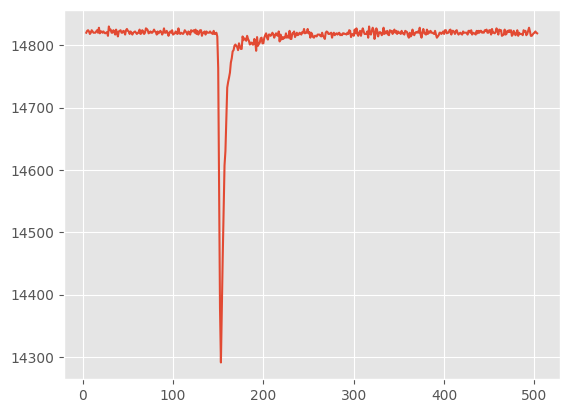

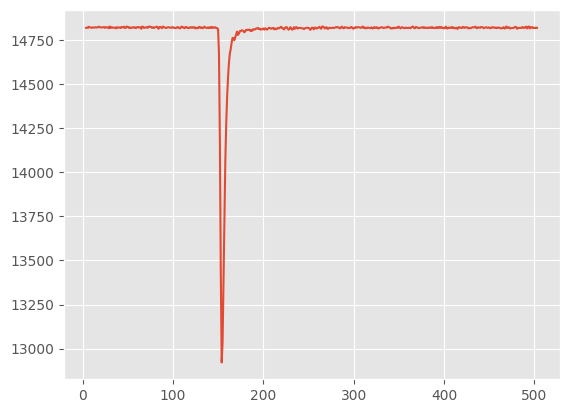

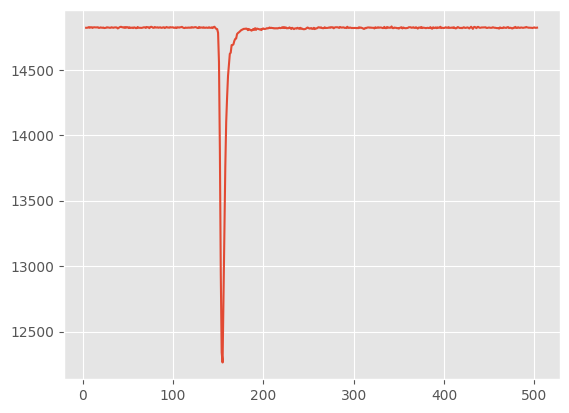

In [23]:
for sample_index in range(3):
    plt.plot(data.iloc[sample_index, :].index, data.iloc[sample_index, :])
    plt.show()

In [48]:
amp = data.min(axis=1)
zero_line = data.iloc[:, :50].mean(axis=1)
std = data.std(axis=1)

upper_bound = zero_line - 3 * std
mask = (data.le(upper_bound, axis=0))

signals_df = data.where(mask)

signals_df

In [96]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

data_np = data.values
n_rows, n_cols = data_np.shape

baseline = data.iloc[:, :50].mean(axis=1).values
std = data.std(axis=1).values
thr = baseline - 3 * std

i_min = data_np.argmin(axis=1)

below_thr = data_np <= thr[:, None]

i_end = np.full(n_rows, -1, dtype=int)

for i in range(n_rows):
    start = i_min[i]
    if start >= n_cols:
        continue
    tail = below_thr[i, start:]
    if not tail.any():
        continue
    exit_idx = np.argmax(~tail)
    i_end[i] = start + exit_idx

areas = []
amplitudes = []

for i in range(n_rows):
    if i_end[i] <= i_min[i]:
        continue

    sig = data_np[i, i_min[i]:i_end[i]]

    sig = baseline[i] - sig

    if len(sig) < 3:
        continue

    area = np.trapezoid(sig)
    amp = sig.max()

    areas.append(area)
    amplitudes.append(amp)

areas = np.array(areas)
amplitudes = np.array(amplitudes)

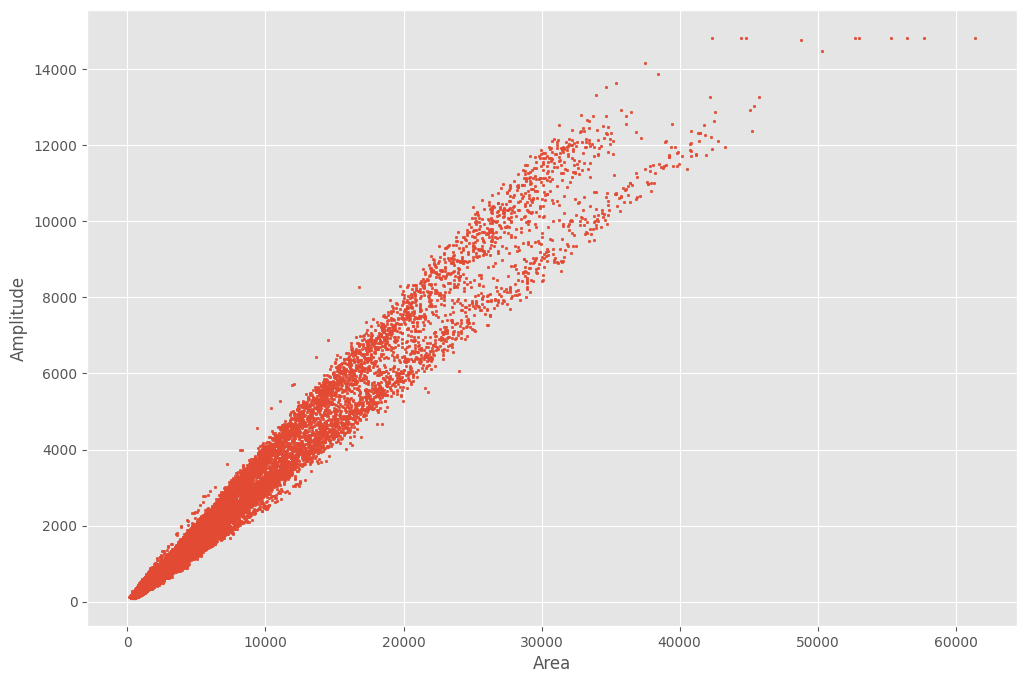

In [95]:
plt.figure(figsize=(12, 8))
plt.scatter(areas, amplitudes, s=3)
plt.xlabel("Area")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

In [107]:
import numpy as np
from sklearn.decomposition import PCA
X = np.array([areas, amplitudes]).T
pca = PCA(n_components=2)
pca.fit(X)
print(pca.components_)

[[ 0.9470076   0.32121116]
 [-0.32121116  0.9470076 ]]


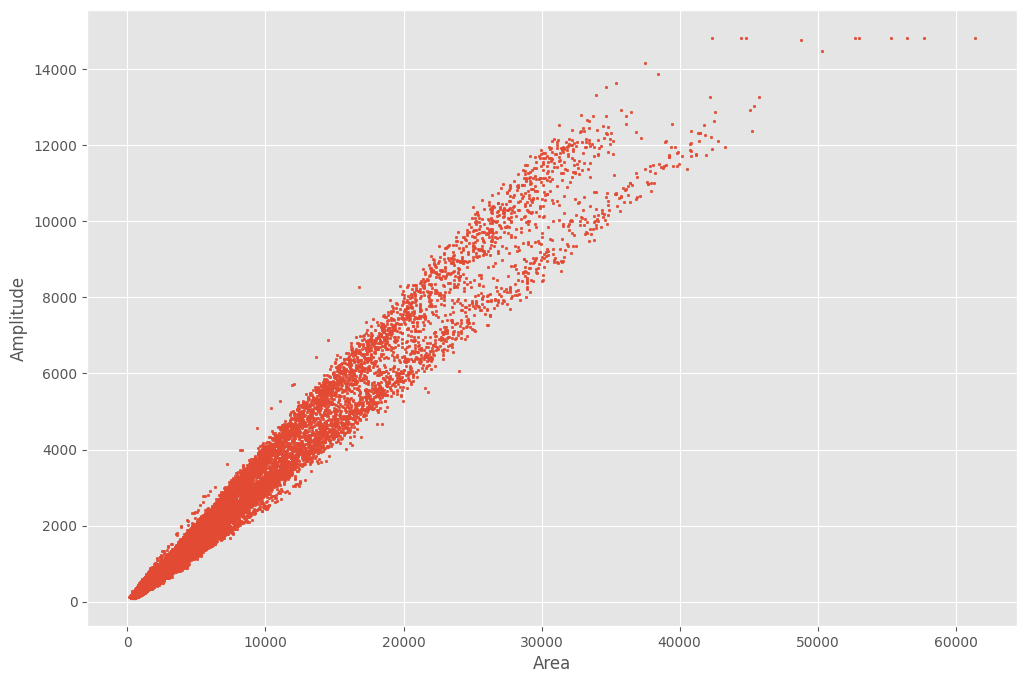

In [139]:
plt.figure(figsize=(12, 8))
plt.scatter(areas, amplitudes, s=3)
plt.xlabel("Area")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

In [110]:
pca.components_[0]

array([0.9470076 , 0.32121116])

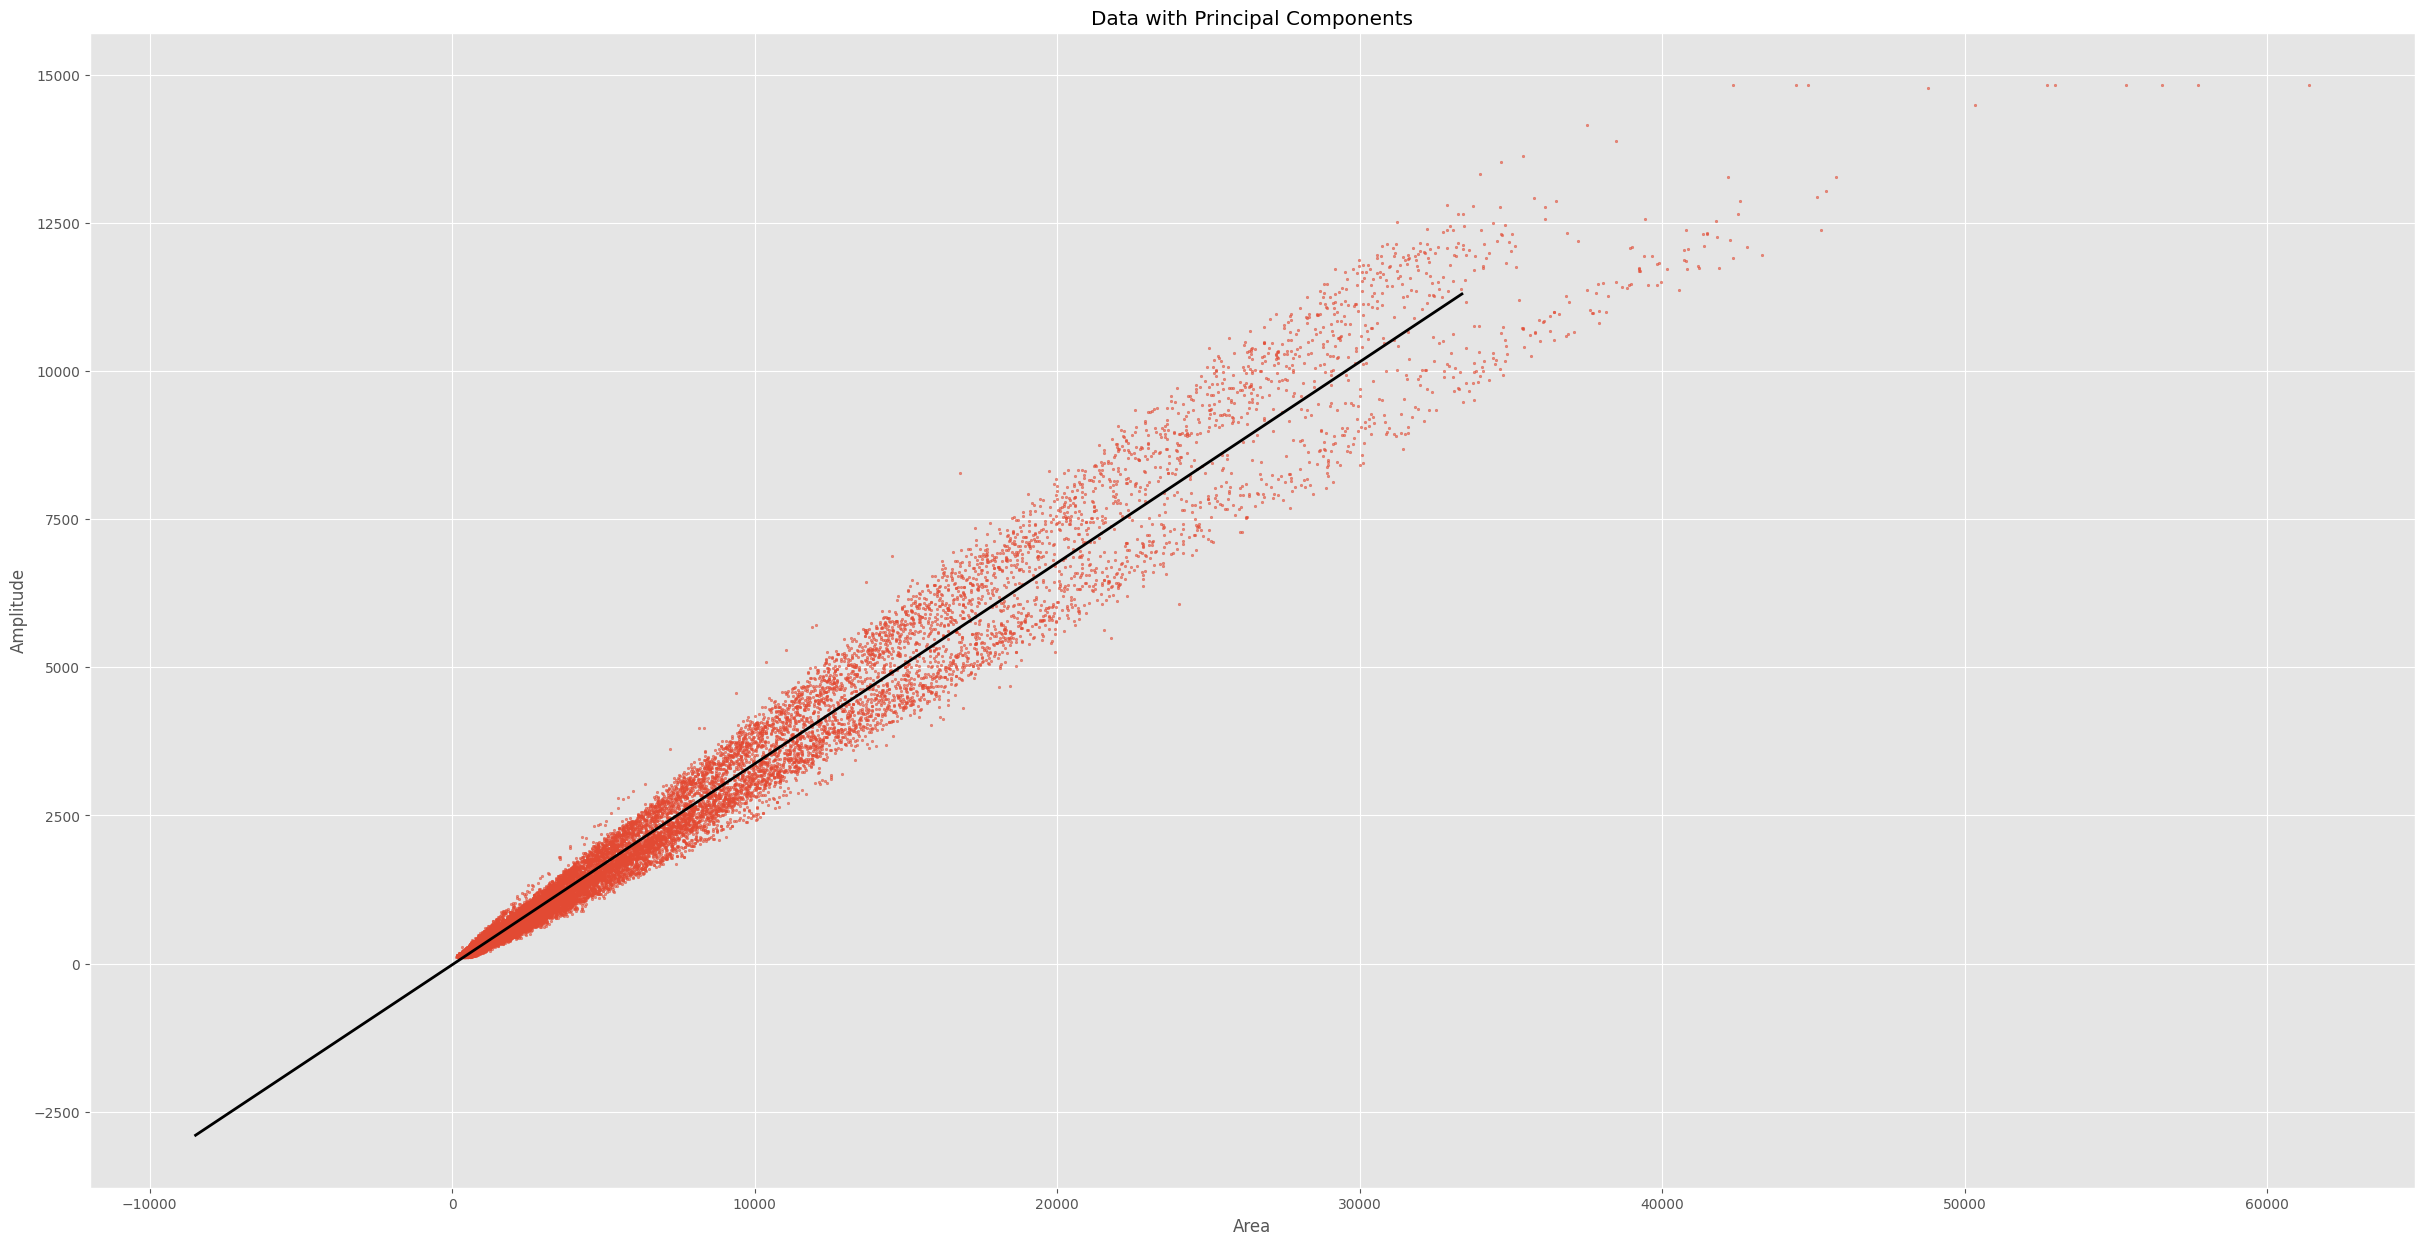

In [123]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

X = np.vstack([areas, amplitudes]).T

pca = PCA(n_components=2)
pca.fit(X)

plt.figure(figsize=(30, 15))
plt.scatter(areas, amplitudes, s=3, alpha=0.6, label='Data points')

mean = pca.mean_
first_component = pca.components_[0]

scale = 2 * np.sqrt(pca.explained_variance_[0])
plt.plot(
    [mean[0] - scale * first_component[0], mean[0] + 2 * scale * first_component[0]],
    [mean[1] - scale * first_component[1], mean[1] + 2 * scale * first_component[1]],
    color="black", linewidth=2
)

plt.xlabel("Area")
plt.ylabel("Amplitude")
plt.grid(True)
plt.title("Data with Principal Components")
plt.show()

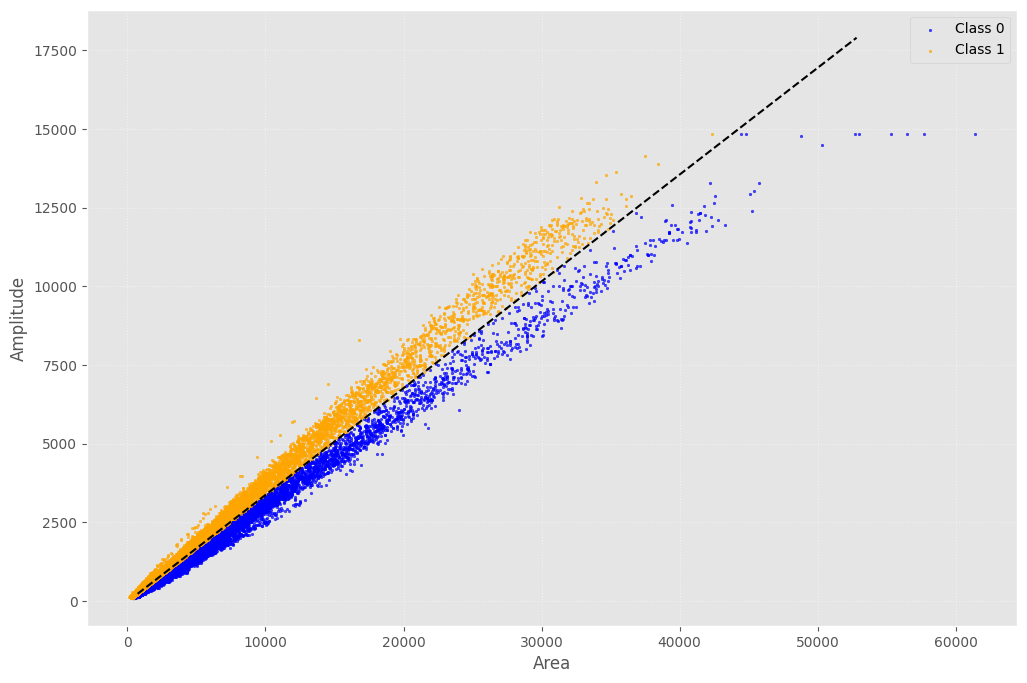

Class 0: 11793
Class 1: 11686


In [142]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

X = np.column_stack([areas, amplitudes])

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

pc1_dir = pca.components_[0]
normal = np.array([-pc1_dir[1], pc1_dir[0]])

dist = np.dot(X - pca.mean_, normal)

labels = (dist > 0).astype(int)

plt.figure(figsize=(12, 8))
colors = ["blue", "orange"]
for cls in [0, 1]:
    mask = labels == cls
    plt.scatter(areas[mask], amplitudes[mask], s=3, c=colors[cls], label=f"Class {cls}", alpha=0.7)

t = np.linspace(-5000, 50_000, 200)
line = pca.mean_ + np.outer(t, pc1_dir)
plt.plot(line[:, 0], line[:, 1], 'k--', linewidth=1.5)

plt.xlabel("Area")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()

print(f"Class 0: {(labels == 0).sum()}")
print(f"Class 1: {(labels == 1).sum()}")

In [145]:
from sklearn.metrics import calinski_harabasz_score, silhouette_score

display(calinski_harabasz_score(X, labels))
silhouette_score(X, labels)

np.float64(24.407115818318513)

np.float64(0.016316179124280496)

In [137]:
import pandas as pd

submission = pd.DataFrame({
    "index": range(len(labels)),
    "cluster": labels
})

submission.to_csv("submission.csv", index=False)